# Apple Detector — Kaggle Training (Synthetik-Sweep + W&B-Tracking)

**Workflow:** Daten einmal hochladen. Pro Sweep-Punkt nur `SYNTHETIC_N` ändern, Trainingsset
aus `/kaggle/input` zusammenbauen (benchmark-frei), trainieren, auf dem **eingefrorenen
Benchmark** evaluieren, und Config + Metriken nach **Weights & Biases** loggen.

> Voraussetzungen:
> 1. Repo-Commits nach GitHub gepusht (das Notebook klont von dort).
> 2. Daten-Dataset als Input angehängt.
> 3. **W&B-API-Key als Kaggle-Secret** `WANDB_API_KEY` hinterlegt
>    (Add-ons → Secrets). Free-Account: wandb.ai → User Settings → API keys.
> 4. Für den Sweep: `SYNTHETIC_N` variieren, alles andere KONSTANT, und jeden Run
>    per **"Save Version" (Save & Run All)** committen.


## Setup

In [1]:
!git clone https://github.com/philippsnr/apple-vision.git
%cd apple-vision

Cloning into 'apple-vision'...
remote: Enumerating objects: 268, done.
remote: Counting objects: 100% (268/268), done.
remote: Compressing objects: 100% (186/186), done.
remote: Total 268 (delta 137), reused 198 (delta 76), pack-reused 0 (from 0)
Receiving objects: 100% (268/268), 8.42 MiB | 13.99 MiB/s, done.
Resolving deltas: 100% (137/137), done.
/kaggle/working/apple-vision


In [2]:
!cd /kaggle/working/apple-vision && git pull && uv sync --quiet

Already up to date.


## Konfiguration — ein Sweep-Punkt

Für den Sweep **nur `SYNTHETIC_N`** variieren. Reale Basis, Seed, Augmentierung, Epochs
über den gesamten Sweep **konstant** halten.

In [3]:
import os

# --- Pfade (KAGGLE_INPUT an deinen Dataset-Slug anpassen!) ---
KAGGLE_INPUT = '/kaggle/input/datasets/philippstaudinger/apple-vision-data'
SYNTH_INPUT  = '/kaggle/input/datasets/philippstaudinger/apple-vision-synthetic'  # eigenes kleines Dataset (nur Synthetik, oft aktualisiert)
REPO = '/kaggle/working/apple-vision'
WORK = '/kaggle/working'

# --- Sweep-Regler: NUR diese Zahl variieren (0, 100, 200, 400, 800, 'all') ---
SYNTHETIC_N = 75

# --- Reale Basis: über den GESAMTEN Sweep fix ---
REAL_SOURCES = {'minneapple': 'all', 'apple_mots': 'all', 'orchard': 'all'}
SEED = 42
VAL_RATIO = 0.1

# --- Training ---
BASE_MODEL = 'fasterrcnn_resnet50_fpn'
EPOCHS = 30
BATCH_SIZE = 4
USE_AMP    = True         # Mixed Precision auf T4: schneller + halber VRAM (bei Batch-Erhöhung nützlich)

# --- Augmentierung: über den GESAMTEN Sweep KONSTANT (sonst Confound) ---
AUG_FACTOR = 1
AUG_FLAGS = '--aug-brightness 0.3 --aug-contrast 0.3 --aug-saturation 0.2 --aug-hue 0.05 --aug-hflip 0.5'

# --- Experiment-Tracking ---
WANDB_PROJECT = 'apple-detector'
RUN_NAME = f'synth{SYNTHETIC_N}-seed{SEED}'

# --- abgeleitete Pfade ---
TRAIN_ROOT   = f'{WORK}/train_set/coco'
TRAIN_MANIFEST = f'{WORK}/train_set/training_manifest.json'
BENCH_ROOT   = f'{KAGGLE_INPUT}/benchmark/coco'
MANIFEST     = f'{KAGGLE_INPUT}/benchmark_manifest.json'
CKPT         = f'{WORK}/checkpoints/fasterrcnn_resnet50_fpn_apple_best.pth'
METRICS_JSON = f'{WORK}/checkpoints/metrics_{RUN_NAME}.json'
os.makedirs(f'{WORK}/checkpoints', exist_ok=True)
print('Sweep-Punkt:', RUN_NAME)


Sweep-Punkt: synth75-seed42


## Check — Input-Dataset vollständig?

In [4]:
import os, json

ok = True
for tag in list(REAL_SOURCES):
    ann = f'{KAGGLE_INPUT}/{tag}/coco/annotations/instances_train.json'
    if os.path.exists(ann):
        print(f'{tag:12s} train images: {len(json.load(open(ann))["images"])}')
    else:
        print(f'{tag:12s} FEHLT: {ann}'); ok = False

sy = f'{SYNTH_INPUT}/synthetic/coco/annotations/instances_train.json'
print('synthetic  :', len(json.load(open(sy))['images']) if os.path.exists(sy) else 'FEHLT (nur nötig fuer synth>0)', 'images')

bench = f'{BENCH_ROOT}/annotations/instances_test.json'
print('benchmark   :', len(json.load(open(bench))['images']) if os.path.exists(bench) else 'FEHLT', 'images')
print('manifest    :', 'OK' if os.path.exists(MANIFEST) else 'FEHLT')
assert ok and os.path.exists(bench) and os.path.exists(MANIFEST), 'Input unvollständig — KAGGLE_INPUT prüfen'


minneapple   train images: 570
apple_mots   train images: 99
orchard      train images: 1955
synthetic  : FEHLT (nur nötig fuer synth>0) images
benchmark   : 150 images
manifest    : OK


## Trainingsset zusammenbauen (aus /kaggle/input, garantiert benchmark-frei)

In [5]:
sources = ' '.join(f'--source {KAGGLE_INPUT}/{tag}/coco:{n}' for tag, n in REAL_SOURCES.items())
sources += f' --source {SYNTH_INPUT}/coco:{SYNTHETIC_N}'

compose = (f'cd {REPO} && uv run python scripts/build_training_set.py {sources} '
           f'--benchmark-manifest {MANIFEST} --output {TRAIN_ROOT} '
           f'--val-ratio {VAL_RATIO} --val-exclude apple-vision-synthetic synthetic --seed {SEED}')
print(compose)
!{compose}


cd /kaggle/working/apple-vision && uv run python scripts/build_training_set.py --source /kaggle/input/datasets/philippstaudinger/apple-vision-data/minneapple/coco:all --source /kaggle/input/datasets/philippstaudinger/apple-vision-data/apple_mots/coco:all --source /kaggle/input/datasets/philippstaudinger/apple-vision-data/orchard/coco:all --source /kaggle/input/datasets/philippstaudinger/apple-vision-synthetic/coco:75 --benchmark-manifest /kaggle/input/datasets/philippstaudinger/apple-vision-data/benchmark_manifest.json --output /kaggle/working/train_set/coco --val-ratio 0.1 --val-exclude apple-vision-synthetic synthetic --seed 42
Leakage-Sperre: 150 Benchmark-Bilder aus 3 Datensätzen geladen
  [minneapple] 620 Bilder (558 train / 62 val), 26011 Boxen (Pool 620)
  [apple_mots] 134 Bilder (121 train / 13 val), 6537 Boxen (Pool 134)
  [orchard] 2249 Bilder (2024 train / 225 val), 15129 Boxen (Pool 2249)
  [apple-vision-synthetic] 75 Bilder (75 train / 0 val), 7394 Boxen (Pool 100)

Fertig

## Training

In [6]:
train = (f'cd {REPO} && MPLBACKEND=agg uv run python -m apple_vision.train '
         f'--dataset-root {TRAIN_ROOT} --epochs {EPOCHS} --batch-size {BATCH_SIZE} --num-workers 4 '
         f'--early-stop-patience 5 {"--amp" if USE_AMP else ""} --aug-factor {AUG_FACTOR} {AUG_FLAGS} '
         f'--out-dir {WORK}/checkpoints')
print(train)
!{train}


cd /kaggle/working/apple-vision && MPLBACKEND=agg uv run python -m apple_vision.train --dataset-root /kaggle/working/train_set/coco --epochs 30 --batch-size 4 --num-workers 4 --early-stop-patience 5 --amp --aug-factor 1 --aug-brightness 0.3 --aug-contrast 0.3 --aug-saturation 0.2 --aug-hue 0.05 --aug-hflip 0.5 --out-dir /kaggle/working/checkpoints
Using device: cuda
Augmentation (train only): brightness=0.3 contrast=0.3 saturation=0.2 hue=0.05 hflip=0.5 scale=0.0 translate=0.0 rotate=0.0
loading annotations into memory...
Done (t=0.25s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|█████████████████████████████████████████| 160M/160M [00:00<00:00, 169MB/s]
AMP (mixed precision): on
Epoch   1/30  train=0.5366  val=0.5397 *
Epoch   2/30  train=

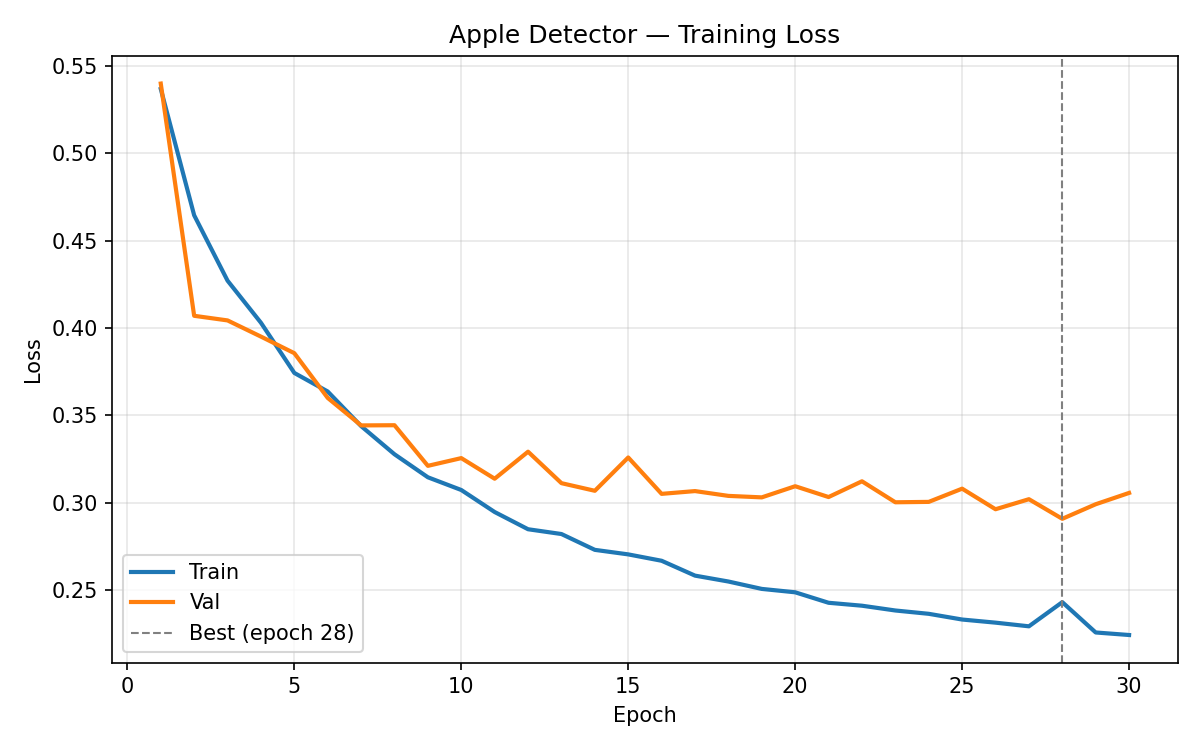

In [7]:
from IPython.display import display, Image
display(Image(filename=f'{WORK}/checkpoints/detector_loss.png'))


## Evaluate — eingefrorener Benchmark (für ALLE Modelle identisch)

Schreibt benannte Metriken (AP, AP50, ...) nach `METRICS_JSON` für W&B + Aggregation.

In [8]:
evalc = (f'cd {REPO} && uv run python -m apple_vision.evaluate_coco '
         f'--dataset-root {BENCH_ROOT} --val-ann annotations/instances_test.json '
         f'--val-images images/test --checkpoint {CKPT} '
         f'--results-json {WORK}/checkpoints/coco_results_{RUN_NAME}.json '
         f'--metrics-json {METRICS_JSON}')
print(evalc)
!{evalc}


cd /kaggle/working/apple-vision && uv run python -m apple_vision.evaluate_coco --dataset-root /kaggle/input/datasets/philippstaudinger/apple-vision-data/benchmark/coco --val-ann annotations/instances_test.json --val-images images/test --checkpoint /kaggle/working/checkpoints/fasterrcnn_resnet50_fpn_apple_best.pth --results-json /kaggle/working/checkpoints/coco_results_synth75-seed42.json --metrics-json /kaggle/working/checkpoints/metrics_synth75-seed42.json
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|███████████████████████████████████████| 97.8M/97.8M [00:00<00:00, 142MB/s]
Saved detections to /kaggle/working/checkpoints/coco_results_synth75-seed42.json
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index creat

## Tracking — Weights & Biases

Loggt **Config (alle Parameter)** + **Benchmark-Metriken** + Loss-Kurve + das Checkpoint
als Artefakt. Im W&B-Web-UI: sortierbare Runs-Tabelle nach AP/AP50, Parameter als Spalten.

In [9]:
import json, os
try:
    import wandb
except ImportError:
    !pip install -q wandb
    import wandb

# API-Key aus Kaggle-Secret
try:
    from kaggle_secrets import UserSecretsClient
    wandb.login(key=UserSecretsClient().get_secret('WANDB_API_KEY'))
    wandb_ok = True
except Exception as e:
    print('W&B-Login übersprungen (Secret WANDB_API_KEY fehlt?):', e)
    wandb_ok = False

if wandb_ok:
    config = {
        'synthetic_n': SYNTHETIC_N, 'real_sources': REAL_SOURCES,
        'seed': SEED, 'val_ratio': VAL_RATIO,
        'base_model': BASE_MODEL, 'epochs': EPOCHS, 'batch_size': BATCH_SIZE,
        'aug_factor': AUG_FACTOR, 'aug_flags': AUG_FLAGS, 'amp': USE_AMP,
    }
    if os.path.exists(TRAIN_MANIFEST):
        tm = json.load(open(TRAIN_MANIFEST))
        config['train_images'] = tm['totals']['train']
        config['val_images'] = tm['totals']['val']
        config['train_boxes'] = sum(s['boxes'] for s in tm['sources'])

    run = wandb.init(project=WANDB_PROJECT, name=RUN_NAME, config=config, reinit=True)

    # Benchmark-Metriken -> summary (= sortierbare Tabellenspalten)
    metrics = json.load(open(METRICS_JSON))
    run.summary.update(metrics)
    print('AP=%.4f  AP50=%.4f' % (metrics['AP'], metrics['AP50']))

    # Loss-Kurve (per Epoche)
    import csv as _csv
    loss_csv = f'{WORK}/checkpoints/detector_metrics.csv'
    if os.path.exists(loss_csv):
        for row in _csv.DictReader(open(loss_csv)):
            wandb.log({'epoch': int(float(row['epoch'])),
                       'train_loss': float(row['train_loss']),
                       'val_loss': float(row['val_loss'])})

    # Checkpoint als Artefakt (an diesen Run gekoppelt)
    if os.path.exists(CKPT):
        art = wandb.Artifact(f'detector-{RUN_NAME}', type='model', metadata=config)
        art.add_file(CKPT)
        run.log_artifact(art)

    run.finish()
    print('W&B:', run.url)


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: philipp-staudinger (philipp-staudinger-dhbw-ravensburg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: setting up run hc685f8u
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/apple-vision/wandb/run-20260706_170023-hc685f8u
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run synth75-seed42
wandb: ⭐️ View project at https://wandb.ai/philipp-

AP=0.4704  AP50=0.8052


wandb: updating run metadata; uploading artifact detector-synth75-seed42
wandb: uploading artifact detector-synth75-seed42
wandb: uploading artifact detector-synth75-seed42; uploading wandb-metadata.json; uploading requirements.txt; uploading output.log; uploading wandb-summary.json (+ 1 more)
wandb: uploading artifact detector-synth75-seed42; uploading wandb-metadata.json; uploading requirements.txt; uploading wandb-summary.json; uploading config.yaml
wandb: uploading artifact detector-synth75-seed42
wandb: uploading history steps 0-29, summary, console lines 0-0
wandb: 
wandb: Run history:
wandb:      epoch ▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
wandb: train_loss █▆▆▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
wandb:   val_loss █▄▄▄▄▃▃▃▂▂▂▂▂▁▂▁▁▁▁▂▁▂▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:        AP 0.47036
wandb:      AP50 0.80521
wandb:      AP75 0.49175
wandb:  AP_large 0.83057
wandb: AP_medium 0.60061
wandb:  AP_small 0.39188
wandb:       AR1 0.02529
wandb:      AR10 0.18747
wandb:     AR100 0.54059
w

W&B: https://wandb.ai/philipp-staudinger-dhbw-ravensburg/apple-detector/runs/hc685f8u


## Visualize — Predictions auf dem Benchmark

In [10]:
vis = (f'cd {REPO} && MPLBACKEND=agg uv run python -m apple_vision.visualize_detections '
       f'--checkpoint {CKPT} --dataset-root {BENCH_ROOT} --split test '
       f'--score-threshold 0.5 --n 8 --out-dir {WORK}/quickplots/detections')
print(vis)
!{vis}


cd /kaggle/working/apple-vision && MPLBACKEND=agg uv run python -m apple_vision.visualize_detections --checkpoint /kaggle/working/checkpoints/fasterrcnn_resnet50_fpn_apple_best.pth --dataset-root /kaggle/input/datasets/philippstaudinger/apple-vision-data/benchmark/coco --split test --score-threshold 0.5 --n 8 --out-dir /kaggle/working/quickplots/detections
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Saved /kaggle/working/quickplots/detections/detection_comparison_00.png
Saved /kaggle/working/quickplots/detections/detection_comparison_01.png
Saved /kaggle/working/quickplots/detections/detection_comparison_02.png
Saved /kaggle/working/quickplots/detections/detection_comparison_03.png
Saved /kaggle/working/quickplots/detections/detection_comparison_04.png
Saved /kaggle/working/quickplots/detections/detection_comparison_05.png
Saved /kaggle/working/quickplots/detections/detection_comparison_06.png
Saved /kaggle/working/quickplots/detections/detection_

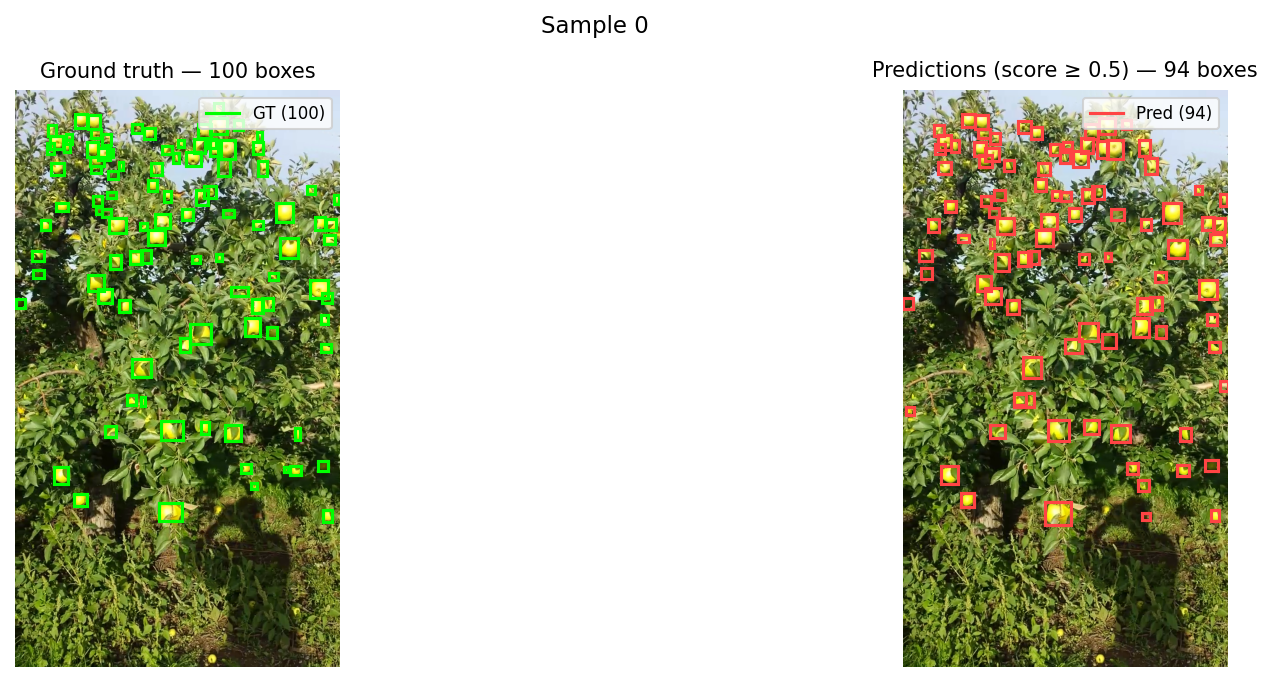

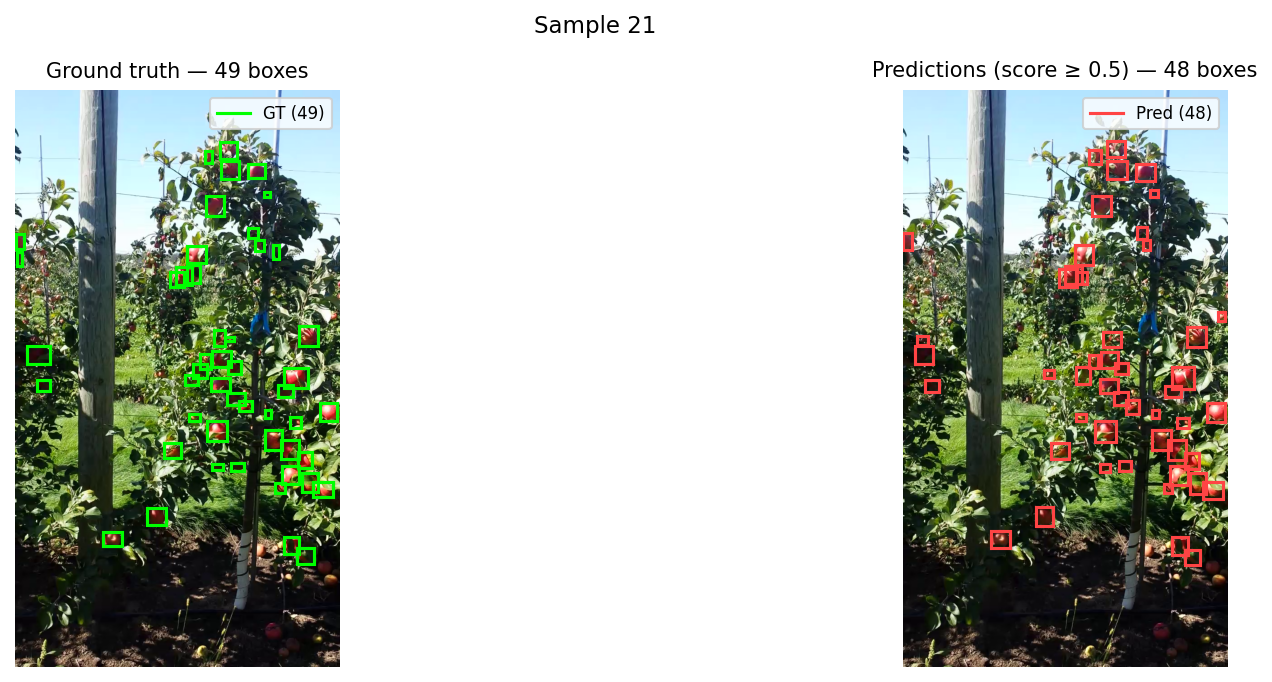

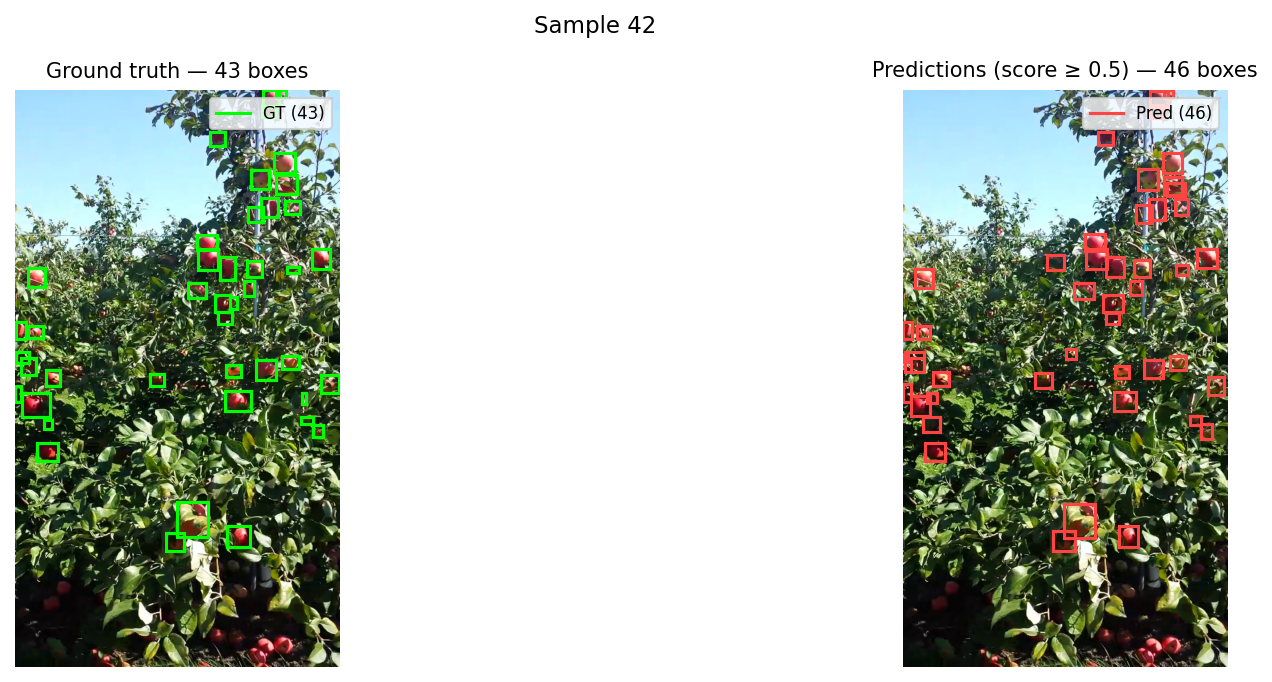

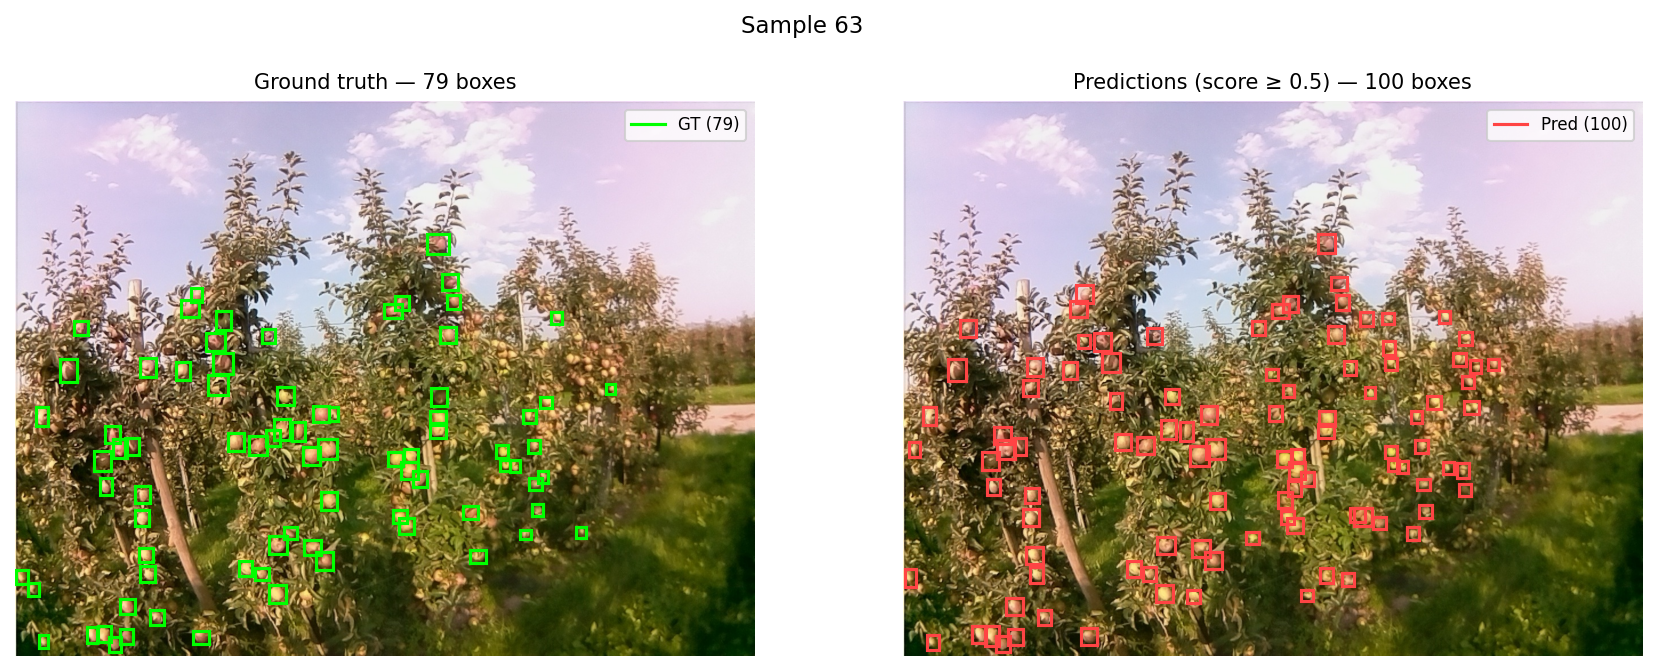

In [11]:
from IPython.display import display, Image
from pathlib import Path
for p in sorted(Path(f'{WORK}/quickplots/detections').glob('*.png'))[:4]:
    display(Image(filename=str(p)))


## (Nach dem Sweep) Bestes Modell in die Kaggle-Model-Registry

Erst ausführen, wenn ein Sieger feststeht — nicht pro Sweep-Punkt. Legt das gewählte
Checkpoint versioniert ab, damit es die 3D-Pipeline wiederverwenden kann.
Handle-Format: `<username>/<model-slug>/<framework>/<variation>`.

In [12]:
# import kagglehub, shutil, os
# upload_dir = f'{WORK}/model_upload'; os.makedirs(upload_dir, exist_ok=True)
# shutil.copy(CKPT, upload_dir)
# kagglehub.model_upload(
#     handle='philippstaudinger/apple-detector/pyTorch/faster-rcnn-r50',
#     local_model_dir=upload_dir,
#     version_notes=RUN_NAME,
# )
